In [ ]:
import torch
from transformers import AutoFeatureExtractor, Wav2Vec2Model
import utils
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model and feature extractor
model_name = "facebook/wav2vec2-base-960h"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = Wav2Vec2Model.from_pretrained(
    model_name,
    attn_implementation="eager"  # Forces explicit output of full attention matrices
)
model.eval()

# 2. Define audio file paths
audio_paths = [
    "../music-clips/classical_8.wav",
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    "../music-clips/classical_6.wav",
    "../music-clips/electronic_1.wav",
    "../music-clips/electronic_10.wav",
    "../music-clips/electronic_14.wav",
    "../music-clips/electronic_3.wav",
]
waveforms = utils.load_process_bulk_audio(audio_paths)
inputs_dict = utils.process_bulk_wave2vec(waveforms, feature_extractor)


# 2. Define the Shuffling Hook
def shuffle_pos_embed_hook(module, input, output):
    """
    output shape from pos_conv_embed: [batch_size, seq_len, hidden_dim]
    """
    batch_size, seq_len, hidden_dim = output.shape
    
    # Generate a random permutation of temporal indices
    permuted_indices = torch.randperm(seq_len)
    
    # Shuffle positional embeddings along the time (seq_len) dimension
    shuffled_output = output[:, permuted_indices, :]
    return shuffled_output

# 3. Register the hook on pos_conv_embed
hook_handle = model.encoder.pos_conv_embed.register_forward_hook(shuffle_pos_embed_hook)

# 3. Extract attention weights per audio file
attentions_dict_shuffled = {}
attentions_dict_clean = {}
# shuffled pos embeddings
with torch.no_grad():
    for path, inputs in inputs_dict.items():
        outputs_shuffled = model(inputs.input_values, output_attentions=True)
        attentions_shuffled = torch.stack(outputs_shuffled.attentions).squeeze(1)
        attentions_dict_shuffled[path] = attentions_shuffled

hook_handle.remove()

# clean pos embeddings
with torch.no_grad():
    for path, inputs in inputs_dict.items():
        outputs_clean = model(inputs.input_values, output_attentions=True)
        attentions_clean = torch.stack(outputs_clean.attentions).squeeze(1)
        attentions_dict_clean[path] = attentions_clean

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
mad_dict_clean = {}
mad_dict_shuffled = {}
for path, attn in attentions_dict_clean.items():
    seq_length = attn.shape[-1]
    print(path, seq_length)
    mean_distances_clean = utils.compute_mad_by_layer(attn, seq_length)
    mad_dict_clean[path] = mean_distances_clean

    mean_distances_shuffled = utils.compute_mad_by_layer(attentions_dict_shuffled.get(path), seq_length)
    mad_dict_shuffled[path] = mean_distances_shuffled

../music-clips/classical_8.wav 3001
../music-clips/classical_1.wav 3001
../music-clips/classical_2.wav 3001
../music-clips/classical_6.wav 3001
../music-clips/electronic_1.wav 2999
../music-clips/electronic_10.wav 2999
../music-clips/electronic_14.wav 2999
../music-clips/electronic_3.wav 2999


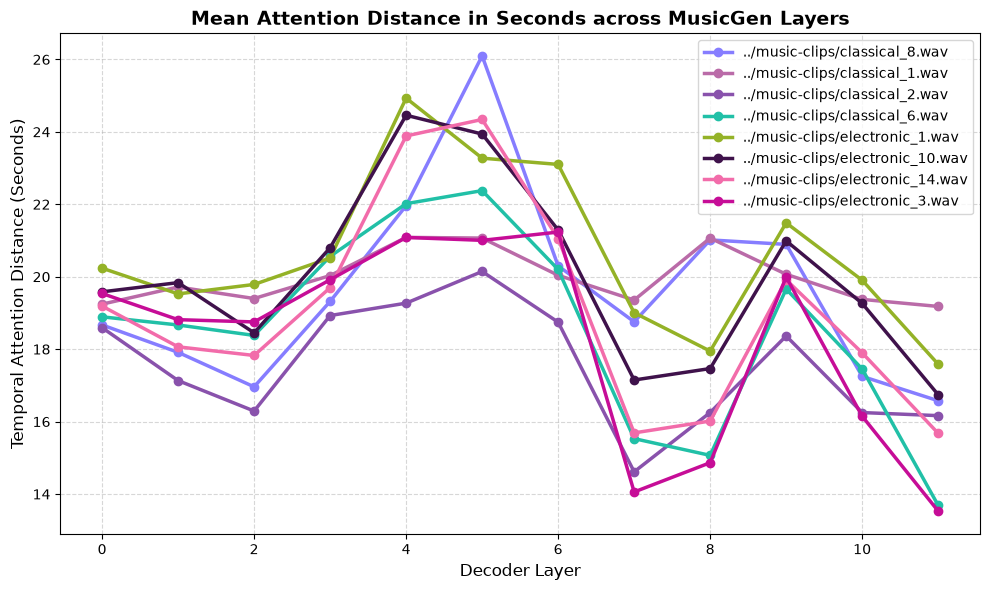

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict_clean.get(path))
    layer_averages_clean = 
    layer_averages_sec = np.mean(mads, axis=1)
    plt.plot(range(num_layers), layer_averages_sec, color=random_hex, linewidth=2.5, marker='o', label=path)

plt.title("Mean Attention Distance in Seconds across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Decoder Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Seconds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()